In [1]:
import pandas as pd
df = pd.read_csv("Creditcard_data.csv")

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df['Class'].value_counts()

Class
0    763
1      9
Name: count, dtype: int64

In [3]:
from sklearn.utils import resample

df_majority = df[df.Class == 0]
df_minority = df[df.Class == 1]

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority])

df_balanced['Class'].value_counts()


Class
0    9
1    9
Name: count, dtype: int64

In [4]:
sampling1 = df_balanced.sample(frac=1, random_state=42)

In [5]:
k = 2
sampling2 = df_balanced.iloc[::k, :]

In [6]:
from sklearn.model_selection import train_test_split

sampling3, _ = train_test_split(
    df_balanced,
    test_size=0.3,
    stratify=df_balanced['Class'],
    random_state=42
)

In [7]:
import numpy as np

# Create 5 clusters based on index
df_balanced = df_balanced.reset_index(drop=True)
df_balanced['Cluster'] = df_balanced.index % 5

# Pick one cluster
sampling4 = df_balanced[df_balanced['Cluster'] == 1].drop('Cluster', axis=1)

sampling4['Class'].value_counts()


Class
0    2
1    2
Name: count, dtype: int64

In [8]:
sampling5 = df_balanced.sample(n=len(df_balanced), replace=True, random_state=42)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    "M1": LogisticRegression(max_iter=1000),
    "M2": DecisionTreeClassifier(),
    "M3": RandomForestClassifier(),
    "M4": SVC(),
    "M5": GaussianNB()
}


In [10]:
from sklearn.metrics import accuracy_score

def evaluate(dataset):
    X = dataset.drop("Class", axis=1)
    y = dataset["Class"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = round(accuracy_score(y_test, y_pred)*100, 2)

    return results


In [11]:
results_table = pd.DataFrame({
    "Sampling1": evaluate(sampling1),
    "Sampling2": evaluate(sampling2),
    "Sampling3": evaluate(sampling3),
    "Sampling4": evaluate(sampling4),
    "Sampling5": evaluate(sampling5)
})

results_table


,Sampling1,Sampling2,Sampling3,Sampling4,Sampling5
M1,66.67,66.67,50.0,50.0,100.00
M2,66.67,66.67,50.0,50.0,50.00
M3,66.67,33.33,50.0,50.0,83.33
M4,66.67,33.33,50.0,50.0,33.33
M5,50.00,33.33,50.0,50.0,83.33


In [12]:
best_sampling = results_table.idxmax(axis=1)
best_sampling

M1    Sampling5
M2    Sampling1
M3    Sampling5
M4    Sampling1
M5    Sampling5
dtype: object

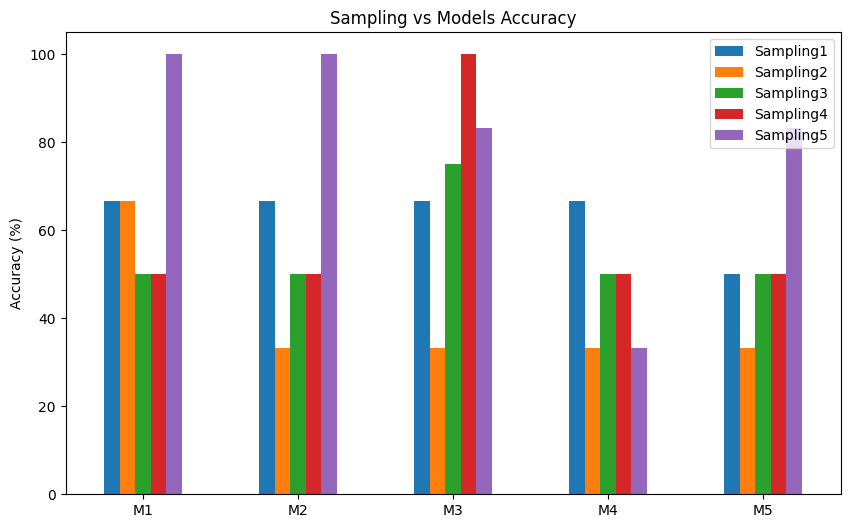

In [18]:
import matplotlib.pyplot as plt

results_table.plot(kind="bar", figsize=(10,6))
plt.title("Sampling vs Models Accuracy")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.show()
